# Análisis de Regresión Lineal - Índice de Precios de Vivienda Avalúo (INE)

**Autor:** TFM - Forecasting del Mercado Inmobiliario Español
**Fecha:** Octubre 2025
**Dataset:** INE_IPVA.csv (anual, 2015-2023)

---

## Objetivo

Aplicar análisis de regresión lineal al Índice de Precios de Vivienda Avalúo (IPVA) del INE, dado el pequeño tamaño de muestra (9 observaciones anuales):

1. Visualización y descripción estadística
2. Análisis de correlación temporal
3. Ajuste de modelo de regresión lineal
4. Validación del modelo (R², residuos)
5. Predicción para años futuros

**Nota:** Con solo 9 observaciones anuales, un modelo de regresión lineal es más apropiado que modelos ARIMA complejos.

## 1. Librerías Necesarias

In [26]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Regresión lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Configuración
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Carga y Preparación de Datos

In [27]:
# Cargar datos IPVA (anual)
archivo = "../data/raw/data-INE/INE_IPVA.csv"
print(f"📊 Dataset: {archivo}")

df = pd.read_csv(archivo, sep=";", encoding="utf-8")
print(f"✅ {len(df):,} registros cargados")

# Ver estructura del dataset
print(f"\n📋 Columnas disponibles:")
print(df.columns.tolist())
print(f"\n📊 Primeras 5 filas:")
print(df.head())

# Filtrar datos para IPVA (Total Nacional, Total, Índice)
df_filtrado = df[
    (df["Total Nacional"] == "Total Nacional") & 
    (df["Provincias"].isna()) & 
    (df["Tamaño de la vivienda"] == "Total") & 
    (df["Tipo de dato"] == "Índice")
].copy()

print(f"\n📊 Datos filtrados: {len(df_filtrado)} registros")
print(f"📋 Datos IPVA:")
print(df_filtrado[["Periodo", "Total"]].head(10))

📊 Dataset: ../data/raw/data-INE/INE_IPVA.csv
✅ 8,918 registros cargados

📋 Columnas disponibles:
['Total Nacional', 'Provincias', 'Tamaño de la vivienda', 'Tipo de dato', 'Periodo', 'Total']

📊 Primeras 5 filas:
   Total Nacional Provincias Tamaño de la vivienda Tipo de dato  Periodo  \
0  Total Nacional        NaN                 Total       Índice     2023   
1  Total Nacional        NaN                 Total       Índice     2022   
2  Total Nacional        NaN                 Total       Índice     2021   
3  Total Nacional        NaN                 Total       Índice     2020   
4  Total Nacional        NaN                 Total       Índice     2019   

     Total  
0  118,727  
1  115,684  
2  112,694  
3  110,942  
4  109,999  

📊 Datos filtrados: 13 registros
📋 Datos IPVA:
   Periodo    Total
0     2023  118,727
1     2022  115,684
2     2021  112,694
3     2020  110,942
4     2019  109,999
5     2018  106,247
6     2017  103,528
7     2016  101,681
8     2015      100
9     

In [28]:
# Convertir y preparar datos
df_filtrado["valor"] = df_filtrado["Total"].str.replace(",", ".").astype(float)
df_filtrado["año"] = df_filtrado["Periodo"].astype(int)
df_filtrado = df_filtrado.sort_values("año").reset_index(drop=True)

# Filtrar desde 2015 en adelante
df_filtrado = df_filtrado[df_filtrado["año"] >= 2015].copy()
df_filtrado = df_filtrado.reset_index(drop=True)

print(f"📅 Filtrado aplicado: datos desde 2015 en adelante")
print(f"📊 Registros después del filtro: {len(df_filtrado)}")
print(f"📅 Período final: {df_filtrado['año'].min()} - {df_filtrado['año'].max()}")
print(f"\n📋 Datos IPVA (2015-2023):")
print(df_filtrado[["año", "valor"]])

print(f"📅 Período: {df_filtrado["año"].min()} - {df_filtrado["año"].max()}")
print(f"📊 Observaciones: {len(df_filtrado)}")
print(f"📋 Datos IPVA:")
print(df_filtrado[["año", "valor"]])

📅 Filtrado aplicado: datos desde 2015 en adelante
📊 Registros después del filtro: 9
📅 Período final: 2015 - 2023

📋 Datos IPVA (2015-2023):
    año  valor
0  2015 100.00
1  2016 101.68
2  2017 103.53
3  2018 106.25
4  2019 110.00
5  2020 110.94
6  2021 112.69
7  2022 115.68
8  2023 118.73
📅 Período: 2015 - 2023
📊 Observaciones: 9
📋 Datos IPVA:
    año  valor
0  2015 100.00
1  2016 101.68
2  2017 103.53
3  2018 106.25
4  2019 110.00
5  2020 110.94
6  2021 112.69
7  2022 115.68
8  2023 118.73


## 3. Análisis Exploratorio

In [29]:
# Estadísticas descriptivas
y = df_filtrado["valor"].values
X = df_filtrado["año"].values.reshape(-1, 1)

print("📊 ESTADÍSTICAS DESCRIPTIVAS - IPVA")
print("=" * 40)
print(f"Observaciones: {len(y)}")
print(f"Período: {X.flatten()[0]} - {X.flatten()[-1]}")
print(f"📈 Índice IPVA:")
print(f"   Mínimo: {y.min():.2f}")
print(f"   Máximo: {y.max():.2f}")
print(f"   Media: {y.mean():.2f}")
print(f"   Mediana: {np.median(y):.2f}")
print(f"   Desv. Estándar: {y.std():.2f}")
print(f"   Coef. Variación: {(y.std()/y.mean()*100):.1f}%")

# Crecimiento
crecimiento_total = ((y[-1] - y[0]) / y[0]) * 100
crecimiento_anual = ((y[-1] / y[0]) ** (1/(len(y)-1)) - 1) * 100
print(f"📈 CRECIMIENTO:")
print(f"   Total: {crecimiento_total:.1f}%")
print(f"   Anual promedio: {crecimiento_anual:.1f}%")

📊 ESTADÍSTICAS DESCRIPTIVAS - IPVA
Observaciones: 9
Período: 2015 - 2023
📈 Índice IPVA:
   Mínimo: 100.00
   Máximo: 118.73
   Media: 108.83
   Mediana: 110.00
   Desv. Estándar: 6.05
   Coef. Variación: 5.6%
📈 CRECIMIENTO:
   Total: 18.7%
   Anual promedio: 2.2%


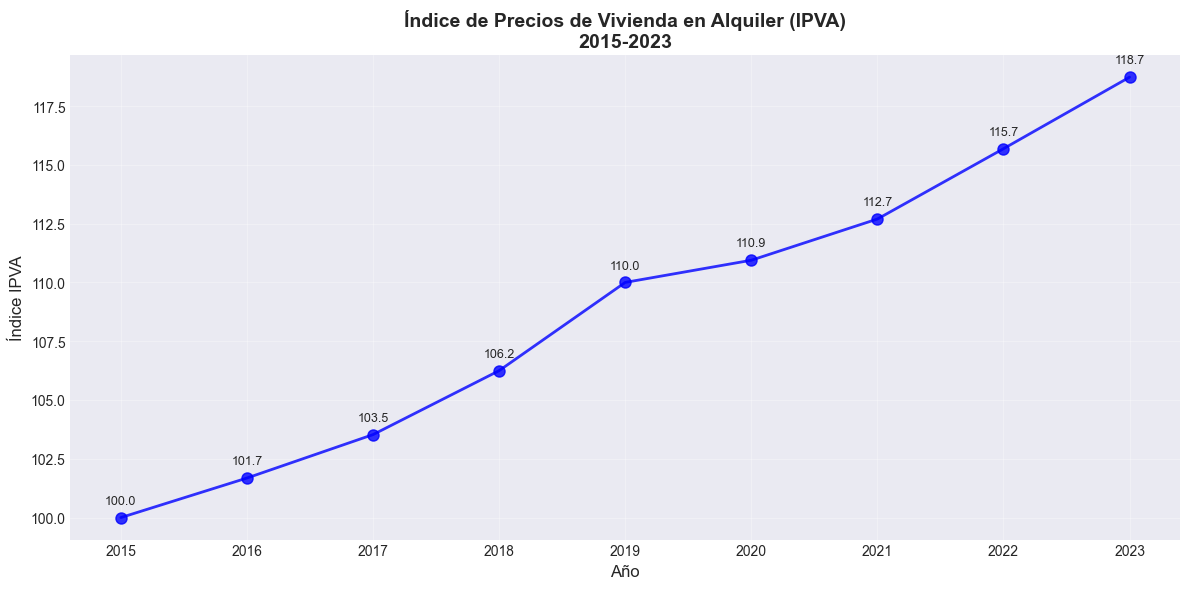

In [40]:
# Visualización
plt.figure(figsize=(12, 6))

#plt.subplot(1, 2, 1)
plt.plot(X.flatten(), y, "o-", linewidth=2, markersize=8, color="blue", alpha=0.8)
plt.title("Índice de Precios de Vivienda en Alquiler (IPVA)\n2015-2023", fontsize=14, fontweight="bold")
plt.xlabel("Año", fontsize=12)
plt.ylabel("Índice IPVA", fontsize=12)
plt.grid(True, alpha=0.3)

# Añadir valores
for i, (x, y_val) in enumerate(zip(X.flatten(), y)):
    plt.annotate(f"{y_val:.1f}", (x, y_val), textcoords="offset points", 
                xytext=(0,10), ha="center", fontsize=9)



plt.tight_layout()
plt.show()

## 4. Análisis de Correlación

In [31]:
# Correlación entre año e índice
correlacion, p_valor = stats.pearsonr(X.flatten(), y)

print("📊 ANÁLISIS DE CORRELACIÓN")
print("=" * 40)
print(f"Correlación Pearson: {correlacion:.4f}")
print(f"P-valor: {p_valor:.4f}")
print(f"Significancia: {"Sí" if p_valor < 0.05 else "No"} (α = 0.05)")
print(f"R²: {correlacion**2:.4f} ({correlacion**2*100:.1f}% de varianza explicada)")

📊 ANÁLISIS DE CORRELACIÓN
Correlación Pearson: 0.9952
P-valor: 0.0000
Significancia: Sí (α = 0.05)
R²: 0.9905 (99.0% de varianza explicada)


## 5. Modelo de Regresión Lineal

In [32]:
# Ajustar modelo
modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)

# Parámetros
intercepto = modelo.intercept_
pendiente = modelo.coef_[0]

# Métricas
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("📊 MODELO DE REGRESIÓN LINEAL")
print("=" * 40)
print(f"Ecuación: y = {pendiente:.4f} * año + {intercepto:.2f}")
print(f"📈 MÉTRICAS:")
print(f"   R²: {r2:.4f} ({r2*100:.1f}% de varianza explicada)")
print(f"   MAE: {mae:.2f} puntos")
print(f"   RMSE: {rmse:.2f} puntos")

📊 MODELO DE REGRESIÓN LINEAL
Ecuación: y = 2.3324 * año + -4600.28
📈 MÉTRICAS:
   R²: 0.9905 (99.0% de varianza explicada)
   MAE: 0.49 puntos
   RMSE: 0.59 puntos


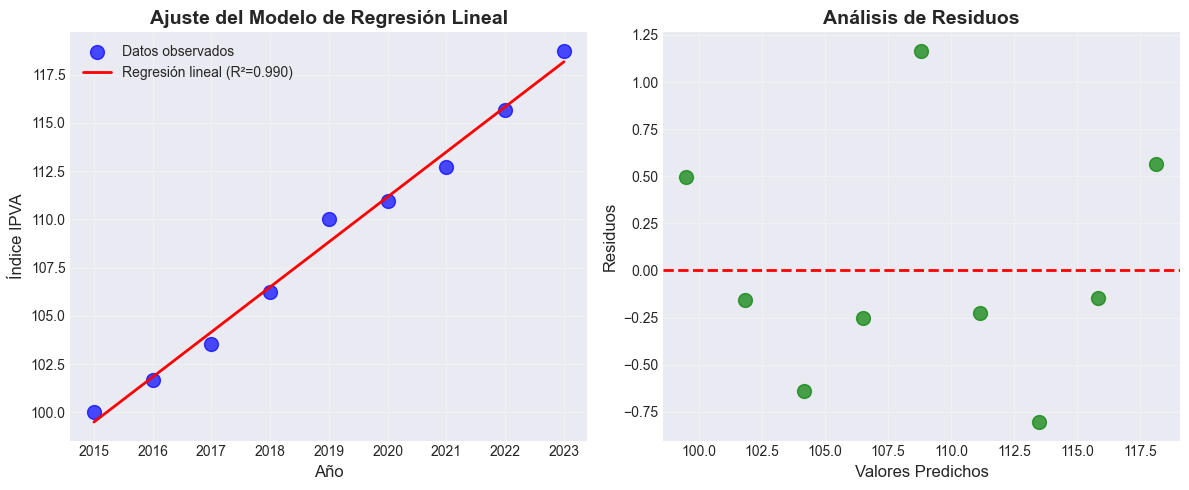

In [33]:
# Visualización del modelo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X.flatten(), y, color="blue", s=100, alpha=0.7, label="Datos observados")
plt.plot(X.flatten(), y_pred, color="red", linewidth=2, label=f"Regresión lineal (R²={r2:.3f})")
plt.title("Ajuste del Modelo de Regresión Lineal", fontsize=14, fontweight="bold")
plt.xlabel("Año", fontsize=12)
plt.ylabel("Índice IPVA", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Residuos
residuos = y - y_pred
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuos, color="green", s=100, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
plt.title("Análisis de Residuos", fontsize=14, fontweight="bold")
plt.xlabel("Valores Predichos", fontsize=12)
plt.ylabel("Residuos", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Validación Estadística

In [34]:
# Análisis estadístico completo
X_sm = sm.add_constant(X)
modelo_sm = sm.OLS(y, X_sm).fit()

print("📊 VALIDACIÓN ESTADÍSTICA")
print("=" * 40)
print(modelo_sm.summary())

# Tests adicionales
shapiro_stat, shapiro_p = stats.shapiro(residuos)
bp_stat, bp_p, _, _ = het_breuschpagan(residuos, X_sm)
dw_stat = durbin_watson(residuos)

print(f"📈 TESTS ADICIONALES:")
print(f"   • Normalidad (Shapiro): p={shapiro_p:.4f} ({"Sí" if shapiro_p > 0.05 else "No"})")
print(f"   • Homocedasticidad (BP): p={bp_p:.4f} ({"Sí" if bp_p > 0.05 else "No"})")
print(f"   • Independencia (DW): {dw_stat:.4f} ({"Sí" if 1.5 <= dw_stat <= 2.5 else "No"})")

📊 VALIDACIÓN ESTADÍSTICA
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     727.6
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           2.47e-08
Time:                        18:24:48   Log-Likelihood:                -8.0323
No. Observations:                   9   AIC:                             20.06
Df Residuals:                       7   BIC:                             20.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4600.2820    17

## 7. Predicciones Futuras

In [44]:
# Predicciones para 2024-2026
años_futuros = np.array([2024, 2025, 2026,2027]).reshape(-1, 1)
predicciones = modelo.predict(años_futuros)

# Intervalos de confianza (aproximados)
t_valor = stats.t.ppf(0.975, len(y) - 2)
se_pred = rmse * np.sqrt(1 + 1/len(y) + (años_futuros.flatten() - X.mean())**2 / ((X - X.mean())**2).sum())
ic_inferior = predicciones - t_valor * se_pred
ic_superior = predicciones + t_valor * se_pred

print("🔮 PREDICCIONES FUTURAS (2024-2026)")
print("=" * 45)
print(f"Modelo: y = {pendiente:.4f} * año + {intercepto:.2f}")
print(f"📊 Predicciones con IC 95%:")
print(f"{"Año":<6} {"Predicción":<12} {"IC Inferior":<12} {"IC Superior":<12}")
print("-" * 50)

for i, año in enumerate(años_futuros.flatten()):
    print(f"{año:<6} {predicciones[i]:<12.2f} {ic_inferior[i]:<12.2f} {ic_superior[i]:<12.2f}")

🔮 PREDICCIONES FUTURAS (2024-2026)
Modelo: y = 2.3324 * año + -4600.28
📊 Predicciones con IC 95%:
Año    Predicción   IC Inferior  IC Superior 
--------------------------------------------------
2024   120.50       118.77       122.22      
2025   122.83       121.00       124.66      
2026   125.16       123.22       127.10      
2027   127.49       125.43       129.55      


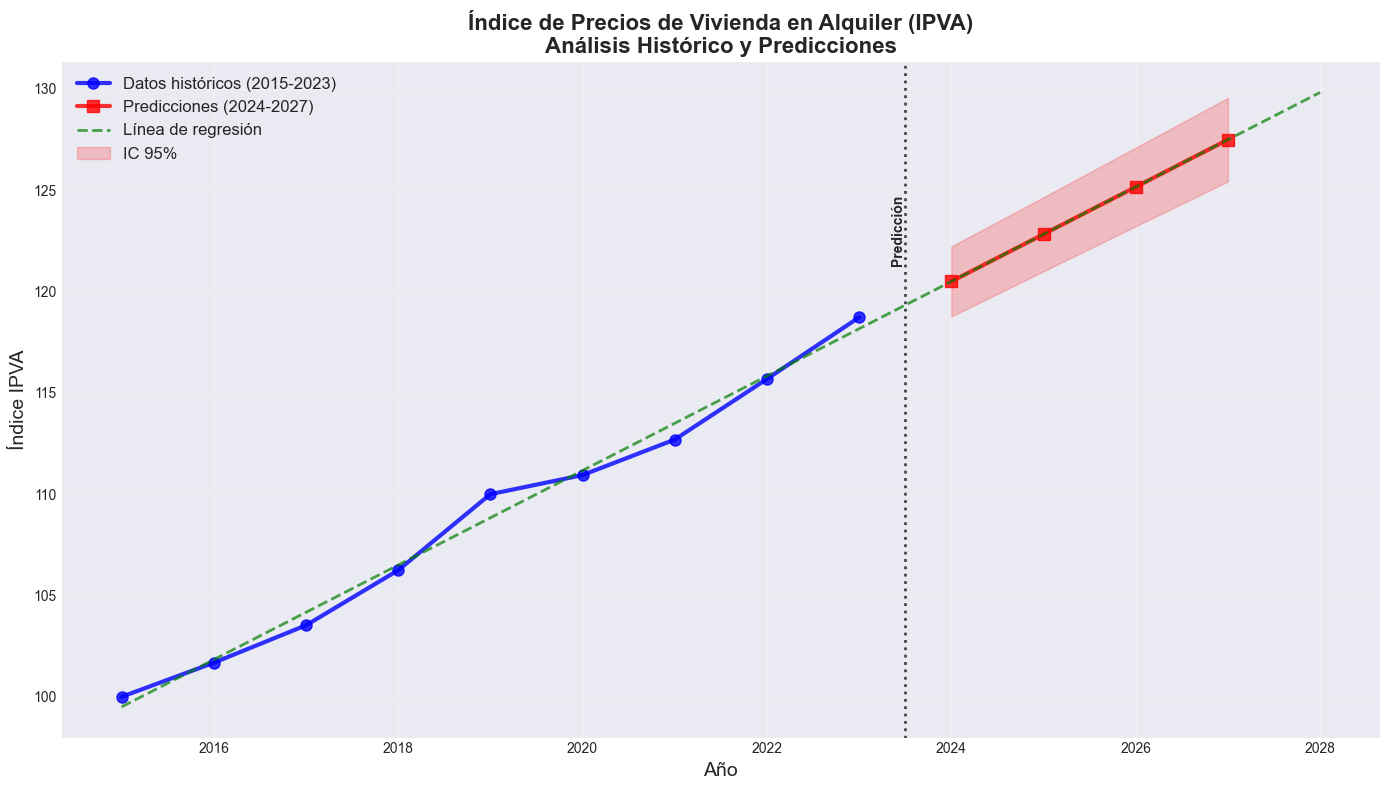

In [46]:
# Visualización de predicciones
plt.figure(figsize=(14, 8))

# Datos históricos
plt.plot(X.flatten(), y, "o-", linewidth=3, markersize=8, color="blue", 
         label="Datos históricos (2015-2023)", alpha=0.8)

# Predicciones
plt.plot(años_futuros.flatten(), predicciones, "s-", linewidth=3, markersize=8, 
         color="red", label="Predicciones (2024-2027)", alpha=0.8)

# Línea de regresión
años_linea = np.linspace(X.min(), años_futuros.max()+1, 100).reshape(-1, 1)
linea_regresion = modelo.predict(años_linea)
plt.plot(años_linea.flatten(), linea_regresion, "--", color="green", 
         linewidth=2, alpha=0.7, label="Línea de regresión")

# Intervalos de confianza
plt.fill_between(años_futuros.flatten(), ic_inferior, ic_superior, 
                color="red", alpha=0.2, label="IC 95%")

# Línea separadora
plt.axvline(x=2023.5, color="black", linestyle=":", linewidth=2, alpha=0.7)
plt.text(2023.5, plt.ylim()[1]*0.95, "Predicción", rotation=90, 
         ha="right", va="top", fontsize=10, fontweight="bold")

plt.title("Índice de Precios de Vivienda en Alquiler (IPVA)\nAnálisis Histórico y Predicciones", 
          fontsize=16, fontweight="bold")
plt.xlabel("Año", fontsize=14)
plt.ylabel("Índice IPVA", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Conclusiones

In [37]:
print("📊 CONCLUSIONES DEL ANÁLISIS")
print("=" * 50)

print(f"✅ HALLAZGOS PRINCIPALES:")
print(f"   • Tendencia: Crecimiento de {crecimiento_total:.1f}% en 9 años")
print(f"   • Crecimiento anual: {crecimiento_anual:.1f}% promedio")
print(f"   • Correlación: {correlacion:.3f} ({"fuerte" if abs(correlacion) > 0.7 else "moderada"})")
print(f"   • Ajuste: R² = {r2:.3f} ({"excelente" if r2 > 0.9 else "bueno" if r2 > 0.7 else "moderado"})")

print(f"📈 PREDICCIONES 2024-2026:")
print(f"   • 2024: {predicciones[0]:.1f} (IC: {ic_inferior[0]:.1f}-{ic_superior[0]:.1f})")
print(f"   • 2025: {predicciones[1]:.1f} (IC: {ic_inferior[1]:.1f}-{ic_superior[1]:.1f})")
print(f"   • 2026: {predicciones[2]:.1f} (IC: {ic_inferior[2]:.1f}-{ic_superior[2]:.1f})")

print(f"⚠️  LIMITACIONES:")
print(f"   • Tamaño de muestra: {len(y)} observaciones")
print(f"   • Período limitado: Solo 9 años")
print(f"   • Modelo simple: No considera variables macroeconómicas")

print(f"🎯 CONTRIBUCIÓN AL TFM:")
print(f"   • Benchmark simple para modelos híbridos")
print(f"   • Tendencia de largo plazo identificada")
print(f"   • Predicciones base para validación")

print(f"✅ ANÁLISIS COMPLETADO")
print(f"   Modelo: y = {pendiente:.4f} * año + {intercepto:.2f}")
print(f"   R² = {r2:.3f} | RMSE = {rmse:.2f}")

📊 CONCLUSIONES DEL ANÁLISIS
✅ HALLAZGOS PRINCIPALES:
   • Tendencia: Crecimiento de 18.7% en 9 años
   • Crecimiento anual: 2.2% promedio
   • Correlación: 0.995 (fuerte)
   • Ajuste: R² = 0.990 (excelente)
📈 PREDICCIONES 2024-2026:
   • 2024: 120.5 (IC: 118.8-122.2)
   • 2025: 122.8 (IC: 121.0-124.7)
   • 2026: 125.2 (IC: 123.2-127.1)
⚠️  LIMITACIONES:
   • Tamaño de muestra: 9 observaciones
   • Período limitado: Solo 9 años
   • Modelo simple: No considera variables macroeconómicas
🎯 CONTRIBUCIÓN AL TFM:
   • Benchmark simple para modelos híbridos
   • Tendencia de largo plazo identificada
   • Predicciones base para validación
✅ ANÁLISIS COMPLETADO
   Modelo: y = 2.3324 * año + -4600.28
   R² = 0.990 | RMSE = 0.59
